# March Machine Learning Mania 2026

Predict NCAA tournament outcomes (men's + women's) using an ensemble of XGBoost, LightGBM, AdaBoost, and TabICL v2.

- **Metric**: Brier score (MSE for binary outcomes)
- **Target**: P(lower TeamID beats higher TeamID)
- **Submission**: Every possible within-gender matchup

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from theme import apply
from utils import (
    load_data, compute_elo, compute_season_stats, compute_massey_features,
    build_seed_map, build_training_data, build_features_vectorized, parse_seed,
    train_or_load, brier_score, leave_one_season_out_cv,
    generate_submission,
    plot_brier_by_season, plot_feature_importance,
    plot_prediction_distribution, plot_calibration_curve,
    plot_model_comparison,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier
from tabicl import TabICLClassifier

warnings.filterwarnings("ignore")
C = apply("mocha")
RANDOM_STATE = 42
print("Setup complete.")

Setup complete.


/home/amanie/Documents/kaggle_march_ml_mania_2026/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Loading

In [2]:
data = load_data()
for name, df in data.items():
    print(f"{name:25s} {str(df.shape):>15s}")

m_teams                          (381, 4)
w_teams                          (379, 2)
m_regular                     (196823, 8)
w_regular                     (140825, 8)
m_regular_detail             (122775, 34)
w_regular_detail              (85505, 34)
m_tourney                       (2585, 8)
w_tourney                       (1717, 8)
m_tourney_detail               (1449, 34)
w_tourney_detail                (961, 34)
m_seeds                         (2626, 3)
w_seeds                         (1744, 3)
m_massey                     (5761702, 5)
sample_sub                    (519144, 2)
sample_sub2                   (132133, 2)


In [3]:
data["m_regular_detail"].head(3)

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23


In [4]:
# Submission structure
print("Stage 1:", data["sample_sub"].shape)
print(data["sample_sub"].head())
print()
print("Stage 2:", data["sample_sub2"].shape)
print(data["sample_sub2"].head())

Stage 1: (519144, 2)
               ID  Pred
0  2022_1101_1102   0.5
1  2022_1101_1103   0.5
2  2022_1101_1104   0.5
3  2022_1101_1105   0.5
4  2022_1101_1106   0.5

Stage 2: (132133, 2)
               ID  Pred
0  2026_1101_1102   0.5
1  2026_1101_1103   0.5
2  2026_1101_1104   0.5
3  2026_1101_1105   0.5
4  2026_1101_1106   0.5


## 3. EDA

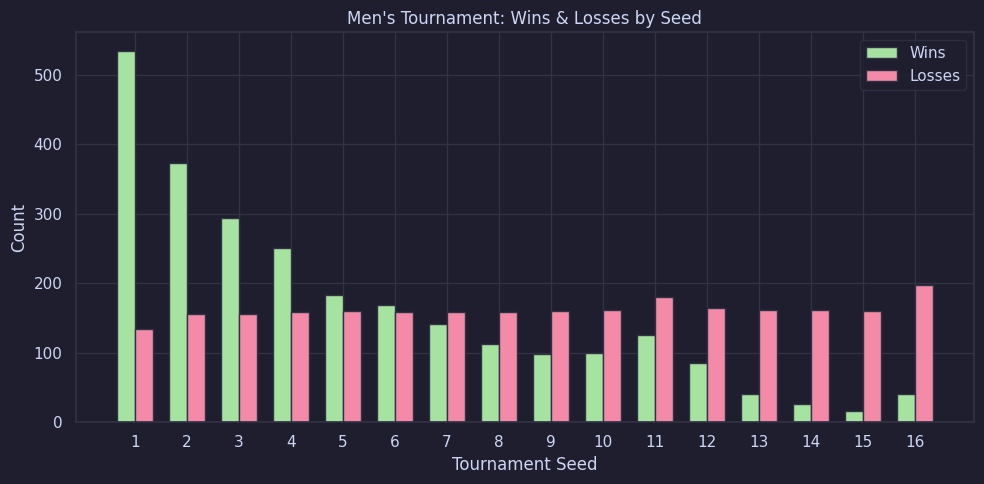

In [5]:
# Seed vs tournament wins (men's)
m_seeds = data["m_seeds"].copy()
m_seeds["SeedNum"] = m_seeds["Seed"].apply(parse_seed)
m_tourney = data["m_tourney"]

# Count wins by seed
w_seeds = m_tourney.merge(m_seeds, left_on=["Season", "WTeamID"], right_on=["Season", "TeamID"])
seed_wins = w_seeds.groupby("SeedNum").size().reindex(range(1, 17), fill_value=0)

l_seeds = m_tourney.merge(m_seeds, left_on=["Season", "LTeamID"], right_on=["Season", "TeamID"])
seed_losses = l_seeds.groupby("SeedNum").size().reindex(range(1, 17), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(1, 17)
w = 0.35
ax.bar(x - w/2, seed_wins.values, w, label="Wins", color=C.green)
ax.bar(x + w/2, seed_losses.values, w, label="Losses", color=C.red)
ax.set_xlabel("Tournament Seed")
ax.set_ylabel("Count")
ax.set_title("Men's Tournament: Wins & Losses by Seed")
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

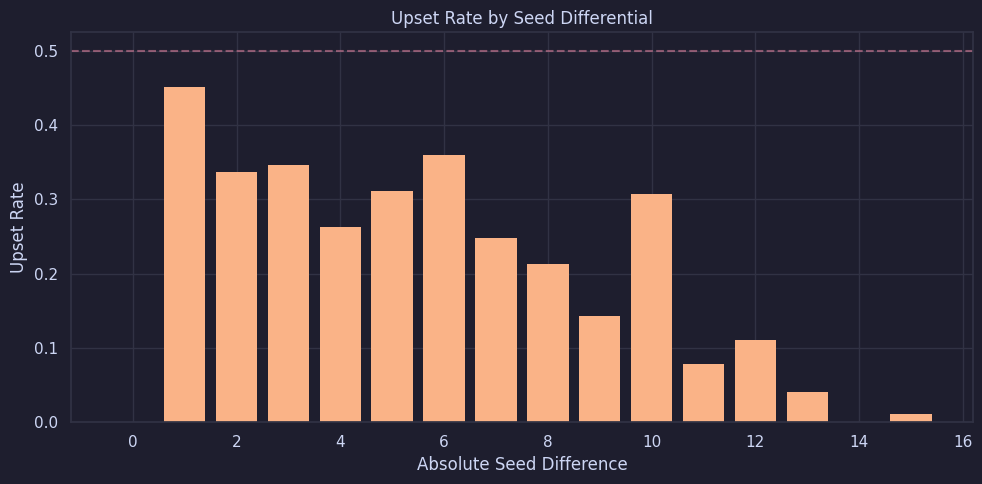

In [6]:
# Upset frequency: how often does the higher seed (worse number) win?
tourney_all = pd.concat([data["m_tourney"], data["w_tourney"]], ignore_index=True)
all_seeds = pd.concat([data["m_seeds"], data["w_seeds"]], ignore_index=True)
all_seeds["SeedNum"] = all_seeds["Seed"].apply(parse_seed)
seed_lookup = dict(zip(zip(all_seeds["Season"], all_seeds["TeamID"]), all_seeds["SeedNum"]))

upsets = []
for _, row in tourney_all.iterrows():
    ws = seed_lookup.get((row["Season"], row["WTeamID"]))
    ls = seed_lookup.get((row["Season"], row["LTeamID"]))
    if ws is not None and ls is not None:
        diff = abs(ws - ls)
        upset = ws > ls  # winner had a worse (higher) seed number
        upsets.append({"SeedDiff": diff, "Upset": int(upset)})

upset_df = pd.DataFrame(upsets)
upset_rate = upset_df.groupby("SeedDiff")["Upset"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(upset_rate.index, upset_rate.values, color=C.peach, edgecolor="none")
ax.axhline(0.5, color=C.red, linestyle="--", alpha=0.5)
ax.set_xlabel("Absolute Seed Difference")
ax.set_ylabel("Upset Rate")
ax.set_title("Upset Rate by Seed Differential")
plt.tight_layout()
plt.show()

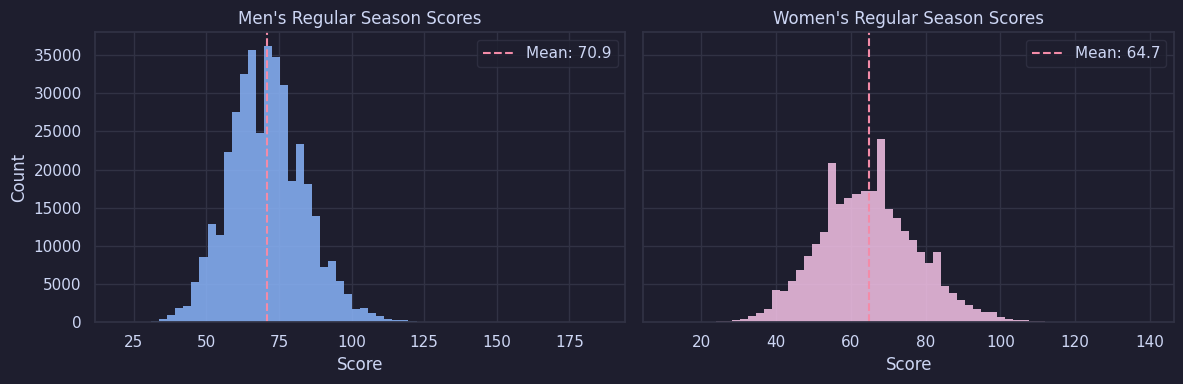

In [7]:
# Score distributions (men's vs women's regular season)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (key, title, color) in zip(axes, [
    ("m_regular", "Men's", C.blue),
    ("w_regular", "Women's", C.pink),
]):
    df = data[key]
    scores = pd.concat([df["WScore"], df["LScore"]])
    ax.hist(scores, bins=60, color=color, edgecolor="none", alpha=0.85)
    ax.set_xlabel("Score")
    ax.set_title(f"{title} Regular Season Scores")
    ax.axvline(scores.mean(), color=C.red, linestyle="--", label=f"Mean: {scores.mean():.1f}")
    ax.legend()

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

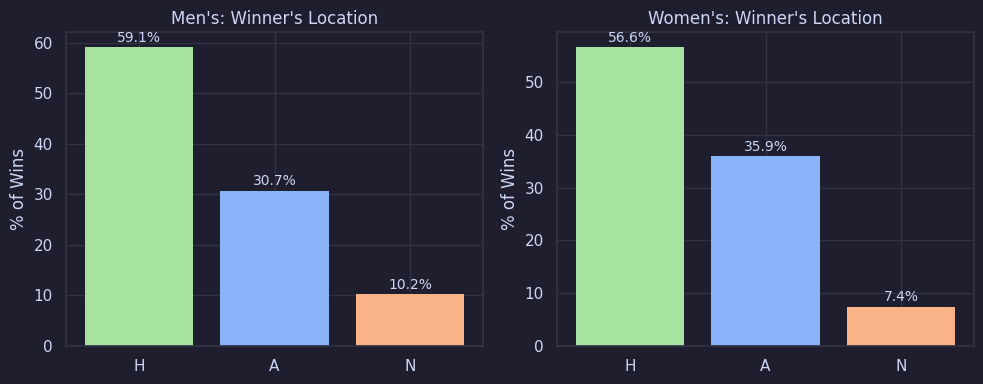

In [8]:
# Home court advantage
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (key, title) in zip(axes, [("m_regular", "Men's"), ("w_regular", "Women's")]):
    df = data[key]
    loc_counts = df["WLoc"].value_counts()
    total_games = len(df)
    pcts = (loc_counts / total_games * 100)
    bars = ax.bar(pcts.index, pcts.values, color=[C.green, C.blue, C.peach][:len(pcts)], edgecolor="none")
    ax.set_ylabel("% of Wins")
    ax.set_title(f"{title}: Winner's Location")
    for bar, pct in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

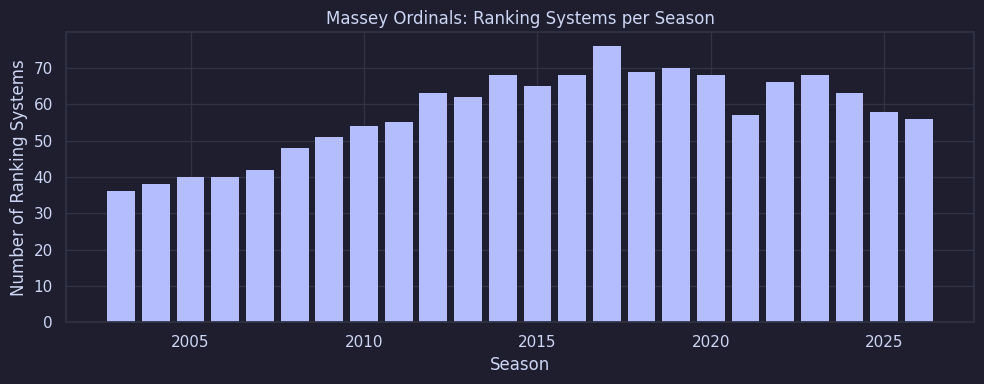

In [9]:
# Massey ordinals: systems per season
massey = data["m_massey"]
systems_per_season = massey.groupby("Season")["SystemName"].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(systems_per_season.index, systems_per_season.values, color=C.lavender, edgecolor="none")
ax.set_xlabel("Season")
ax.set_ylabel("Number of Ranking Systems")
ax.set_title("Massey Ordinals: Ranking Systems per Season")
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [10]:
# Elo: previous season (end-of-season, includes tournament) — long-term baseline
m_elo_prev = compute_elo(data["m_regular"], data["m_tourney"], include_tourney=True)
w_elo_prev = compute_elo(data["w_regular"], data["w_tourney"], include_tourney=True)
elo_prev = {**m_elo_prev, **w_elo_prev}
print(f"Previous-season Elo: {len(elo_prev):,} ratings")

Previous-season Elo: 24,158 ratings


In [11]:
# Elo: current season (regular season only, no tournament games) — current form
m_elo_curr = compute_elo(data["m_regular"], include_tourney=False)
w_elo_curr = compute_elo(data["w_regular"], include_tourney=False)
elo_curr = {**m_elo_curr, **w_elo_curr}
print(f"Current-season Elo: {len(elo_curr):,} ratings")

Current-season Elo: 24,158 ratings


In [12]:
# Seeds, season stats, Massey
seed_map  = build_seed_map(data["m_seeds"], data["w_seeds"])
print(f"Seed map: {len(seed_map):,} entries")

m_stats = compute_season_stats(data["m_regular_detail"])
w_stats = compute_season_stats(data["w_regular_detail"])
stats_df = pd.concat([m_stats, w_stats], ignore_index=True)
print(f"Season stats: {len(stats_df):,} team-seasons")

massey_df = compute_massey_features(data["m_massey"], day_threshold=128)
print(f"Massey features: {len(massey_df):,} team-seasons")

Seed map: 4,370 entries
Season stats: 14,311 team-seasons
Massey features: 7,980 team-seasons


In [13]:
# Sanity check: top men's teams by end-of-2025 Elo
m_teams_lut = dict(zip(data["m_teams"]["TeamID"], data["m_teams"]["TeamName"]))
top_m = sorted(
    [(m_teams_lut.get(tid, tid), r) for (s, tid), r in elo_prev.items()
     if s == 2025 and tid < 2000],
    key=lambda x: -x[1]
)[:10]
print("Top 10 men's teams by end-of-2025 Elo:")
for i, (name, elo) in enumerate(top_m, 1):
    print(f"  {i:2d}. {name}: {elo:.0f}")

Top 10 men's teams by end-of-2025 Elo:
   1. Houston: 1862
   2. Florida: 1820
   3. Duke: 1816
   4. Auburn: 1792
   5. Alabama: 1767
   6. Tennessee: 1765
   7. Drake: 1752
   8. Connecticut: 1744
   9. Michigan St: 1740
  10. St Mary's CA: 1738


## 5. Training Data

In [14]:
# Build training data from historical tournament results (2003+)
X, y, seasons = build_training_data(
    data["m_tourney"], data["w_tourney"],
    elo_prev, elo_curr, seed_map, stats_df, massey_df,
    min_season=2003,
)

FEATURE_COLS = list(X.columns)

print(f"Training set: {X.shape[0]:,} games, {X.shape[1]} features")
print(f"Seasons: {seasons.min()}–{seasons.max()}")
print(f"y balance (Team1 win rate): {y.mean():.3f}  ← should be ~0.5")
print("\nNaN counts (features with missing values):")
nan_counts = X.isna().sum()
print(nan_counts[nan_counts > 0])

Training set: 2,851 games, 20 features
Seasons: 2003–2025
y balance (Team1 win rate): 0.505  ← should be ~0.5

NaN counts (features with missing values):
WinPctDiff             441
AvgScoreMarginDiff     441
FGPctDiff              441
FG3PctDiff             441
FTPctDiff              441
AvgORDiff              441
AvgDRDiff              441
AvgAstDiff             441
AvgTODiff              441
AvgStlDiff             441
AvgBlkDiff             441
OppFGPctDiff           441
OppFG3PctDiff          441
MasseyMeanDiff        1402
MasseyMedianDiff      1402
dtype: int64


In [15]:
X.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
EloPrevDiff,2851.0,4.046,168.629,-579.517,-105.505,-0.553,118.741,614.535
EloCurrDiff,2851.0,2.590,131.147,-496.926,-76.983,-0.114,81.946,465.076
SeedT1,2851.0,6.776,4.682,1.000,3.000,6.000,11.000,16.000
SeedT2,2851.0,6.643,4.602,1.000,3.000,6.000,10.000,16.000
SeedDiff,2851.0,-0.133,7.415,-15.000,-5.000,0.000,5.000,15.000
WinPctDiff,2410.0,0.005,0.155,-0.633,-0.097,0.007,0.106,0.548
AvgScoreMarginDiff,2410.0,0.742,8.486,-33.073,-4.255,0.278,5.288,41.879
FGPctDiff,2410.0,0.005,0.039,-0.141,-0.021,0.005,0.028,0.155
FG3PctDiff,2410.0,0.003,0.040,-0.140,-0.024,0.003,0.028,0.155
FTPctDiff,2410.0,-0.000,0.053,-0.181,-0.037,0.000,0.037,0.183


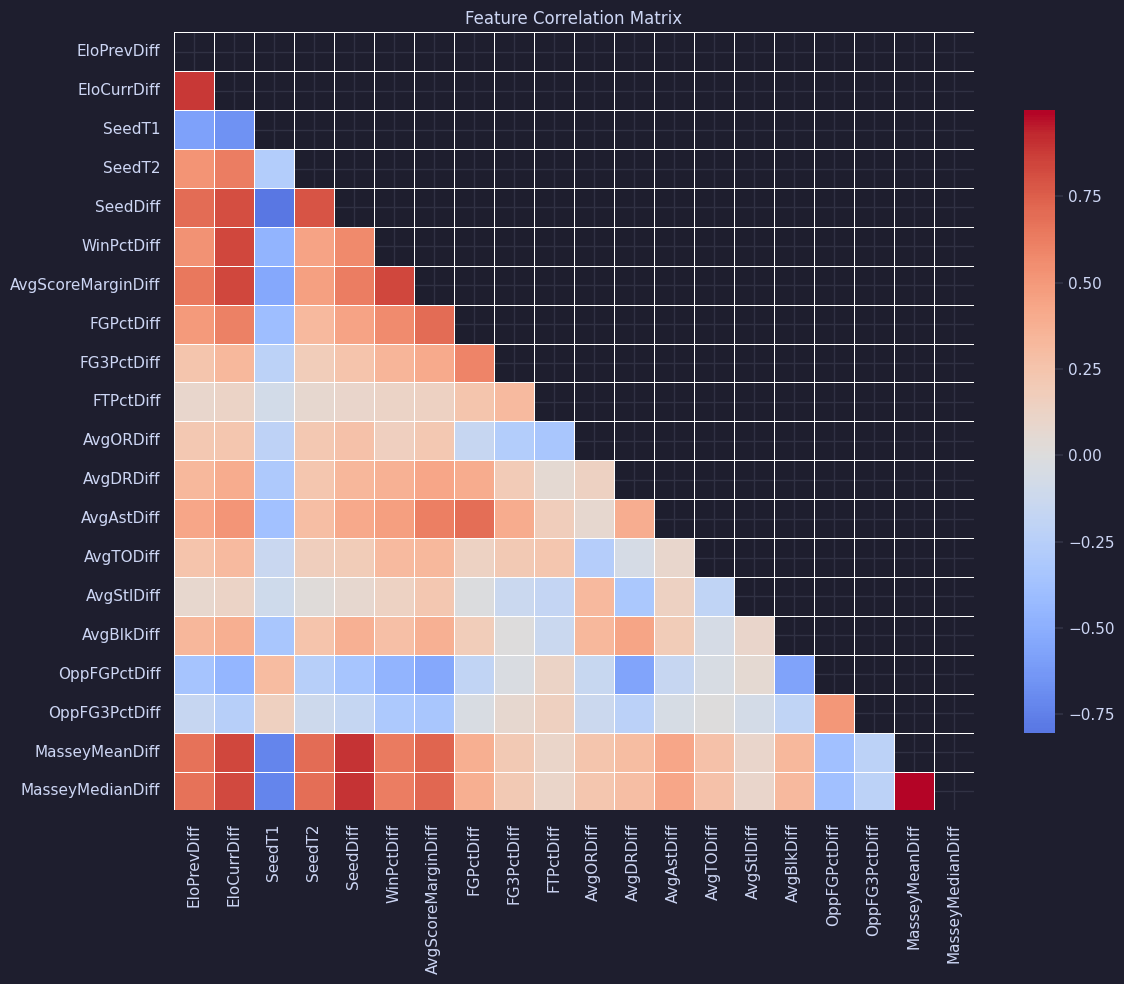

In [16]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [17]:
# Compute training-set medians for NaN imputation (AdaBoost, TabICL)
IMPUTE_MEDIANS = X.median().to_dict()
print("Imputation medians ready.")

Imputation medians ready.


## 6. Model Training with LOSO CV

**Leave-one-season-out (LOSO)** trains on all seasons except one, evaluates on the held-out season.
This matches the competition's temporal structure and avoids data leakage.

In [18]:
# XGBoost
xgb_params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0],
}

xgb_model = train_or_load(
    "xgboost",
    XGBClassifier,
    X.values, y.values,
    param_dist=xgb_params,
    random_state=RANDOM_STATE,
    model_kwargs={"eval_metric": "logloss", "verbosity": 0},
    n_iter=50, cv=5, scoring="neg_brier_score", n_jobs=-1,
)

print("\nXGBoost LOSO CV:")
xgb_cv = leave_one_season_out_cv(
    lambda: XGBClassifier(**xgb_model.get_params()),
    X, y, seasons,
)

[cache] Loaded xgboost from disk.

XGBoost LOSO CV:
  LOSO mean Brier: 0.1675


In [19]:
# LightGBM
lgbm_params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7, -1],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_samples": [5, 10, 20],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0],
}

lgbm_model = train_or_load(
    "lightgbm",
    LGBMClassifier,
    X.values, y.values,
    param_dist=lgbm_params,
    random_state=RANDOM_STATE,
    model_kwargs={"verbose": -1},
    n_iter=50, cv=5, scoring="neg_brier_score", n_jobs=-1,
)

print("\nLightGBM LOSO CV:")
lgbm_cv = leave_one_season_out_cv(
    lambda: LGBMClassifier(**lgbm_model.get_params()),
    X, y, seasons,
)

[cache] Loaded lightgbm from disk.

LightGBM LOSO CV:
  LOSO mean Brier: 0.1672


In [20]:
# AdaBoost (NaN imputation required)
ada_params = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
}

X_imputed = X.fillna(IMPUTE_MEDIANS)

ada_model = train_or_load(
    "adaboost",
    AdaBoostClassifier,
    X_imputed.values, y.values,
    param_dist=ada_params,
    random_state=RANDOM_STATE,
    n_iter=20, cv=5, scoring="neg_brier_score", n_jobs=-1,
)

print("\nAdaBoost LOSO CV (with imputation):")
ada_cv = leave_one_season_out_cv(
    lambda: AdaBoostClassifier(**ada_model.get_params()),
    X, y, seasons,
    impute=True,
)

Best params: {'n_estimators': 100, 'learning_rate': 0.05}

AdaBoost LOSO CV (with imputation):
  LOSO mean Brier: 0.1730


In [21]:
# TabICL v2 — pretrained foundation model, no hyperparameter search
tabicl_model = train_or_load("tabicl", TabICLClassifier, X_imputed.values, y.values,
                              param_dist=None, model_kwargs={"n_estimators": 16})

print("\nTabICL LOSO CV (with imputation):")
tabicl_cv = leave_one_season_out_cv(
    lambda: TabICLClassifier(n_estimators=16, random_state=RANDOM_STATE),
    X, y, seasons,
    impute=True,
)

INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.


TabICL LOSO CV (with imputation):
  LOSO mean Brier: 0.1637


In [22]:
# CV summary table
cv_results = {
    "XGBoost":  xgb_cv,
    "LightGBM": lgbm_cv,
    "AdaBoost": ada_cv,
    "TabICL":   tabicl_cv,
}

cv_df = pd.DataFrame(cv_results).sort_index()
cv_df.loc["Mean"] = cv_df.mean()
print(cv_df.round(4).to_string())

      XGBoost  LightGBM  AdaBoost  TabICL
2003   0.1553    0.1537    0.1644  0.1425
2004   0.1697    0.1676    0.1748  0.1675
2005   0.1700    0.1697    0.1749  0.1663
2006   0.1667    0.1706    0.1752  0.1661
2007   0.1587    0.1547    0.1569  0.1625
2008   0.1361    0.1350    0.1445  0.1257
2009   0.1609    0.1605    0.1698  0.1641
2010   0.1675    0.1652    0.1712  0.1652
2011   0.1781    0.1738    0.1804  0.1674
2012   0.1608    0.1606    0.1633  0.1534
2013   0.1847    0.1820    0.1884  0.1806
2014   0.1805    0.1813    0.1834  0.1764
2015   0.1472    0.1452    0.1560  0.1362
2016   0.1847    0.1894    0.1889  0.1814
2017   0.1609    0.1600    0.1712  0.1583
2018   0.1800    0.1806    0.1852  0.1835
2019   0.1534    0.1509    0.1641  0.1496
2021   0.1902    0.1913    0.2001  0.1851
2022   0.1868    0.1918    0.1917  0.1839
2023   0.1912    0.1988    0.1904  0.1962
2024   0.1610    0.1572    0.1650  0.1588
2025   0.1415    0.1390    0.1469  0.1302
Mean   0.1675    0.1672    0.1730 

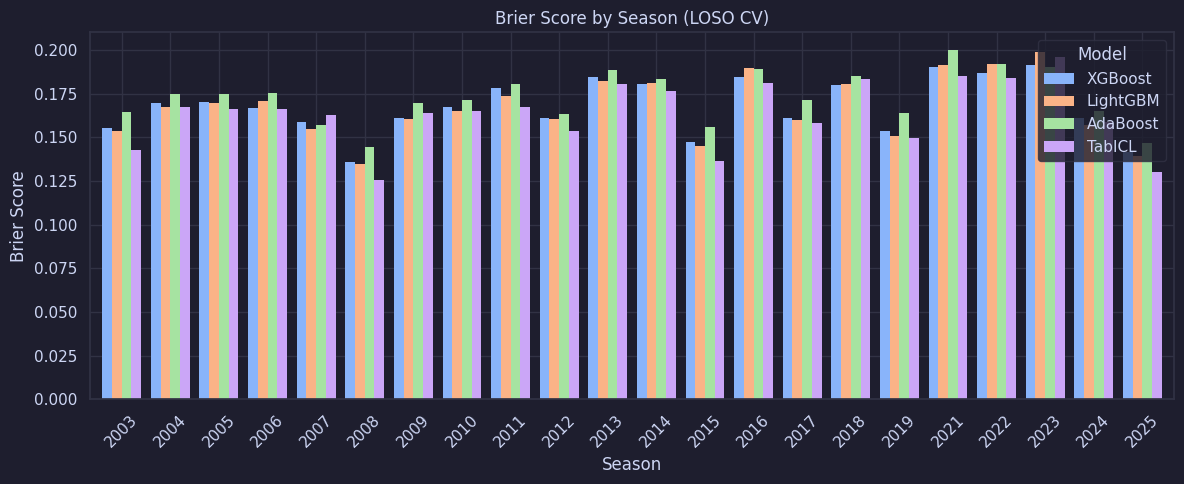

In [23]:
plot_brier_by_season(cv_results, C.cycle)
plt.show()

## 7. Ensemble

In [ ]:
# Inverse-Brier weighting — AdaBoost excluded (hurts ensemble)
ensemble_models = {k: v for k, v in cv_results.items() if k != "AdaBoost"}
mean_briers = {name: np.mean(list(s.values())) for name, s in ensemble_models.items()}
inv = {name: 1.0 / b for name, b in mean_briers.items()}
total = sum(inv.values())
weights = {name: v / total for name, v in inv.items()}

print("Model performance and ensemble weights:")
for name, b in sorted(mean_briers.items(), key=lambda x: x[1]):
    print(f"  {name:10s}  Brier={b:.4f}  weight={weights[name]:.3f}")
print(f"  {'AdaBoost':10s}  Brier={np.mean(list(cv_results['AdaBoost'].values())):.4f}  EXCLUDED")

In [ ]:
# Validate ensemble with full LOSO (re-train all models per fold)
ensemble_cv = {}
for season in sorted(seasons.unique()):
    train_mask = seasons != season
    test_mask  = seasons == season

    X_tr, X_te = X[train_mask].copy(), X[test_mask].copy()
    y_tr, y_te = y[train_mask].values, y[test_mask].values
    tr_medians  = X_tr.median().to_dict()
    X_tr_imp    = X_tr.fillna(tr_medians)
    X_te_imp    = X_te.fillna(tr_medians)

    fold_preds = np.zeros(len(y_te))

    m1 = XGBClassifier(**xgb_model.get_params())
    m1.fit(X_tr.values, y_tr)
    fold_preds += weights["XGBoost"] * m1.predict_proba(X_te.values)[:, 1]

    m2 = LGBMClassifier(**lgbm_model.get_params())
    m2.fit(X_tr.values, y_tr)
    fold_preds += weights["LightGBM"] * m2.predict_proba(X_te.values)[:, 1]

    m4 = TabICLClassifier(n_estimators=16, random_state=RANDOM_STATE)
    m4.fit(X_tr_imp.values, y_tr)
    fold_preds += weights["TabICL"] * m4.predict_proba(X_te_imp.values)[:, 1]

    ensemble_cv[season] = brier_score(y_te, fold_preds)

mean_briers["Ensemble"] = np.mean(list(ensemble_cv.values()))
print(f"Ensemble mean Brier: {mean_briers['Ensemble']:.4f}")
print(pd.Series(ensemble_cv, name="Brier").sort_index().round(4))

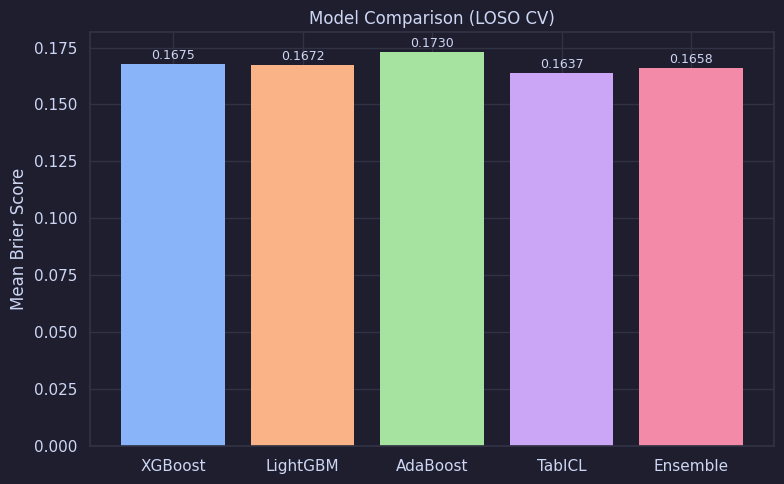

In [26]:
plot_model_comparison(mean_briers, C.cycle)
plt.show()

## 8. Submission Generation

In [ ]:
models = {
    "XGBoost":  xgb_model,
    "LightGBM": lgbm_model,
    "TabICL":   tabicl_model,
}

In [ ]:
# Stage 1: seasons 2022–2025
sub1 = generate_submission(
    data["sample_sub"], models, weights,
    elo_prev, elo_curr, seed_map, stats_df, massey_df,
    feature_cols=FEATURE_COLS,
    impute_medians=IMPUTE_MEDIANS,
)
sub1.to_csv("submission_stage1.csv", index=False)
print(f"Stage 1: {sub1.shape[0]:,} rows")
print(f"Range : [{sub1['Pred'].min():.4f}, {sub1['Pred'].max():.4f}]")
print(f"Mean  : {sub1['Pred'].mean():.4f}  Std: {sub1['Pred'].std():.4f}")
sub1.head()

Building features...
  Feature matrix: (519144, 20)
  XGBoost: mean=0.5068, std=0.1669
  LightGBM: mean=0.5070, std=0.1844
  AdaBoost: mean=0.5243, std=0.1253


In [ ]:
# Stage 2: season 2026
sub2 = generate_submission(
    data["sample_sub2"], models, weights,
    elo_prev, elo_curr, seed_map, stats_df, massey_df,
    feature_cols=FEATURE_COLS,
    impute_medians=IMPUTE_MEDIANS,
)
sub2.to_csv("submission_stage2.csv", index=False)
print(f"Stage 2: {sub2.shape[0]:,} rows")
print(f"Range : [{sub2['Pred'].min():.4f}, {sub2['Pred'].max():.4f}]")
print(f"Mean  : {sub2['Pred'].mean():.4f}  Std: {sub2['Pred'].std():.4f}")
sub2.head()

## 9. Validation Visualizations

In [ ]:
plot_prediction_distribution(sub1["Pred"], color=C.blue)
plt.title("Stage 1: Prediction Distribution")
plt.show()

In [ ]:
# Feature importance: XGBoost and LightGBM
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_feature_importance(xgb_model,  FEATURE_COLS, top_n=15, color=C.blue,  ax=axes[0])
plot_feature_importance(lgbm_model, FEATURE_COLS, top_n=15, color=C.peach, ax=axes[1])
axes[0].set_title("XGBoost Feature Importance")
axes[1].set_title("LightGBM Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Calibration curve on LOSO held-out predictions (proper out-of-fold)
oof_preds = np.zeros(len(y))
for season in sorted(seasons.unique()):
    train_mask = seasons != season
    test_mask  = seasons == season
    m = XGBClassifier(**xgb_model.get_params())
    m.fit(X[train_mask].values, y[train_mask].values)
    oof_preds[test_mask] = m.predict_proba(X[test_mask].values)[:, 1]

plot_calibration_curve(y.values, oof_preds, color=C.blue)
plt.title("XGBoost Calibration (LOSO out-of-fold)")
plt.show()

In [ ]:
# Men's vs Women's prediction distributions (Stage 1)
ids_parsed = sub1["ID"].str.split("_", expand=True).astype(int)
is_mens = ids_parsed[1] < 2000

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (mask, title, color) in zip(axes, [
    (is_mens,  "Men's",   C.blue),
    (~is_mens, "Women's", C.pink),
]):
    preds_sub = sub1.loc[mask.values, "Pred"]
    ax.hist(preds_sub, bins=50, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(0.5, color=C.red, linestyle="--", alpha=0.6)
    ax.set_xlabel("P(Team1 wins)")
    ax.set_title(f"{title} ({len(preds_sub):,} matchups)")
axes[0].set_ylabel("Count")
plt.suptitle("Stage 1: Prediction Distribution by Gender")
plt.tight_layout()
plt.show()

In [ ]:
# Sanity check: seed-based predictions for 2024
check_season = 2024
check_sub = sub1[sub1["ID"].str.startswith(f"{check_season}_")].copy()
check_ids = check_sub["ID"].str.split("_", expand=True).astype(int)
check_ids.columns = ["Season", "T1", "T2"]
check_ids["Seed1"] = check_ids.apply(lambda r: seed_map.get((r["Season"], r["T1"])), axis=1)
check_ids["Seed2"] = check_ids.apply(lambda r: seed_map.get((r["Season"], r["T2"])), axis=1)
check_ids["Pred"]  = check_sub["Pred"].values

seeded = check_ids.dropna(subset=["Seed1", "Seed2"])
print(f"Seeded matchups in {check_season}: {len(seeded):,}")

vs1_16 = seeded[(seeded["Seed1"] == 1) & (seeded["Seed2"] == 16)]
print(f"\n1 vs 16 seed predictions (expect >0.5 for Team1):")
print(vs1_16[["T1", "T2", "Seed1", "Seed2", "Pred"]].round(3).to_string(index=False))

vs8_9  = seeded[(seeded["Seed1"] == 8) & (seeded["Seed2"] == 9)]
print(f"\n8 vs 9 seed predictions (expect ~0.5):")
print(vs8_9[["T1", "T2", "Seed1", "Seed2", "Pred"]].round(3).to_string(index=False))